In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/sample_submission.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/train.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/test.csv


In [2]:
# 1) Imports & settings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
# catboost is optional on Kaggle; if available:
# from catboost import CatBoostClassifier

RANDOM_STATE = 42


In [3]:
# 2) Load data
train = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/train.csv')
test = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


Train shape: (29500, 14)
Test shape: (7000, 13)


,id,adults,children,weekends,weekdays,meal_type,room_type,arrival,lead_time,segment,repeat,price,requests,booking_status
0,0,2,0,0,1,Not Selected,Room_Type 1,2018-05-21,54.0,Online,0,116.10,0,1
1,1,1,0,3,6,Not Selected,Room_Type 1,2018-11-12,12.0,Online,0,71.87,1,1
2,2,2,0,0,2,Meal Plan 1,Room_Type 2,2018-01-06,34.0,Online,0,71.55,1,0
3,3,1,0,2,1,Meal Plan 1,Room_Type 1,2018-02-14,4.0,Corporate,1,66.00,0,0
4,4,2,0,2,3,Meal Plan 1,Room_Type 1,2018-07-08,155.0,Offline,0,72.25,0,0


In [4]:
# 3) Data types (rubric: explicitly state types)
dtypes = pd.DataFrame(train.dtypes, columns=['dtype'])
dtypes['n_missing'] = train.isna().sum()
dtypes['n_unique'] = train.nunique()
dtypes
# In the notebook: write a short cell that lists which columns are numeric / categorical / datetime / id.


,dtype,n_missing,n_unique
id,int64,0,29500
adults,int64,0,5
children,int64,0,6
weekends,int64,0,7
weekdays,int64,0,18
meal_type,object,0,4
room_type,object,841,7
arrival,object,0,550
lead_time,float64,1695,347
segment,object,0,5


In [5]:
# 4) Descriptive statistics (numeric)
train.describe().T[['min','25%','50%','75%','max','mean','std']]
# Also show medians explicitly if you like:
train.median(numeric_only=True)


id                14749.50
adults                2.00
children              0.00
weekends              1.00
weekdays              2.00
lead_time            58.00
repeat                0.00
price                99.88
requests              0.00
booking_status        0.00
dtype: float64

In [6]:
# 5) Missing values
missing = train.isna().sum().sort_values(ascending=False)
missing[missing>0]
# Plan: for numeric -> median; for categorical -> 'Missing' or most frequent; for dates -> consider imputing or flagging


lead_time    1695
price        1583
room_type     841
dtype: int64

In [7]:
# 6) Duplicates
print("Duplicate rows:", train.duplicated().sum())
# If duplicates > 0:
train = train.drop_duplicates()


Duplicate rows: 0


In [8]:
# 7) Outlier detection (rubric: identify & justify)
# Example: use IQR for numeric columns
num_cols = train.select_dtypes(include=['int64','float64']).columns.tolist()
def iqr_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    return (df[col] < lower) | (df[col] > upper)

outlier_summary = {c: iqr_outliers(train,c).sum() for c in num_cols}
pd.Series(outlier_summary).sort_values(ascending=False).head(10)
# Decision: either cap, transform (log), or keep depending on business sense. Document that choice.


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


adults            8263
children          2227
price             1336
lead_time          905
repeat             767
requests           617
weekdays           252
weekends            14
id                   0
booking_status       0
dtype: int64

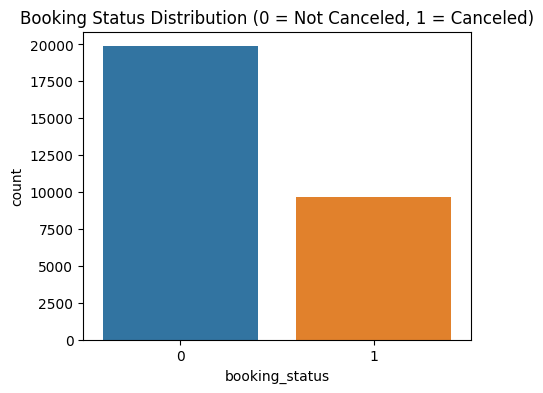

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1) Target Distribution ---
plt.figure(figsize=(5,4))
sns.countplot(x='booking_status', data=train)
plt.title('Booking Status Distribution (0 = Not Canceled, 1 = Canceled)')
plt.show()

# Insight:
# If the class distribution is imbalanced, models may need class weights or stratified CV.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


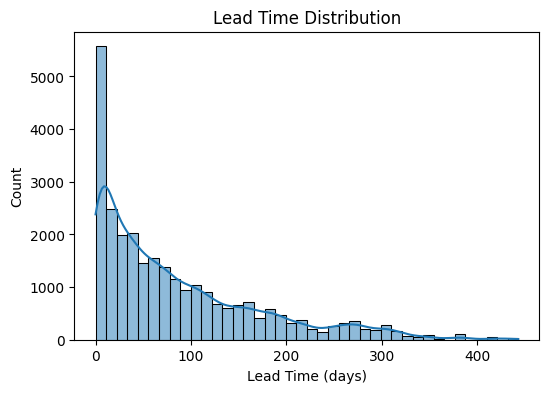

In [10]:
# --- 2) Lead Time Distribution ---
plt.figure(figsize=(6,4))
sns.histplot(train['lead_time'], bins=40, kde=True)
plt.title('Lead Time Distribution')
plt.xlabel('Lead Time (days)')
plt.show()

# Insight:
# Longer lead times often correlate with higher cancellation probability in hotel datasets.


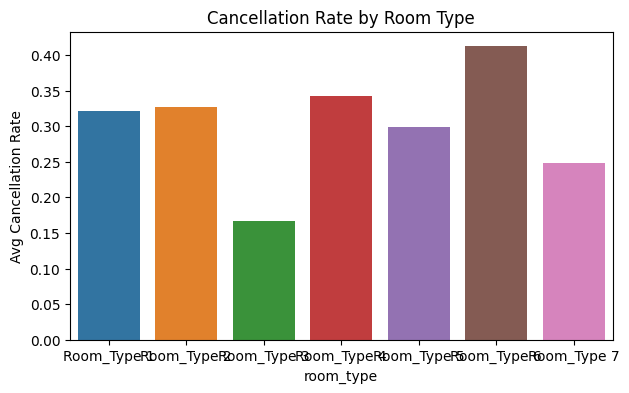

In [11]:
# --- 3) Cancellation Rate by Room Type ---
room_cancel = train.groupby('room_type')['booking_status'].mean().reset_index()

plt.figure(figsize=(7,4))
sns.barplot(x='room_type', y='booking_status', data=room_cancel)
plt.title('Cancellation Rate by Room Type')
plt.ylabel('Avg Cancellation Rate')
plt.show()

# Insight:
# Understanding which room types have higher cancellations helps in pricing & overbooking strategy.


In [12]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd

# Identify target
target = "booking_status"

# Numerical & Categorical columns based on your dataset
num_cols = ['adults', 'children', 'weekends', 'weekdays',
            'lead_time', 'repeat', 'price', 'requests']

cat_cols = ['meal_type', 'room_type', 'arrival', 'segment']

# Numerical pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline (NO warnings)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Full preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])


In [13]:
from sklearn.model_selection import train_test_split

# Features and labels
X = train.drop(columns=[target])
y = train[target]

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit the preprocessor on training data
preprocessor.fit(X_train)

# Transform the data
X_train_preprocessed = preprocessor.transform(X_train)
X_val_preprocessed   = preprocessor.transform(X_val)

print("Shapes:")
print("X_train_preprocessed:", X_train_preprocessed.shape)
print("X_val_preprocessed:", X_val_preprocessed.shape)


Shapes:
X_train_preprocessed: (23600, 574)
X_val_preprocessed: (5900, 574)


In [14]:
# -----------------------------
# STEP 11: Train 7 Models
# -----------------------------

# Imports (no missing definitions)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC  # faster than SVC
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(
        tree_method='hist',
        eval_metric='logloss',
        n_estimators=200,
        learning_rate=0.1
    ),
    "Naive Bayes": GaussianNB(),
    "Linear SVM": LinearSVC(max_iter=2000)
}

results = {}

for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train_preprocessed, y_train)
    preds = model.predict(X_val_preprocessed)
    acc = accuracy_score(y_val, preds)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}\n")


Training Logistic Regression ...
Logistic Regression Accuracy: 0.8153

Training Decision Tree ...
Decision Tree Accuracy: 0.8631

Training Random Forest ...
Random Forest Accuracy: 0.8868

Training Gradient Boosting ...
Gradient Boosting Accuracy: 0.8434

Training XGBoost ...
XGBoost Accuracy: 0.8627

Training Naive Bayes ...
Naive Bayes Accuracy: 0.4824

Training Linear SVM ...
Linear SVM Accuracy: 0.8149



/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [15]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

rf_params = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 6, 8, 10, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(n_jobs=-1),
    param_distributions=rf_params,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_preprocessed, y_train)
print("Best RF Params:", rf_random.best_params_)
print("Best RF Score:", rf_random.best_score_)


Best RF Params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
Best RF Score: 0.8588558957857878


In [16]:
from sklearn.tree import DecisionTreeClassifier

dt_params = {
    "max_depth": [3, 5, 7, 9, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy"]
}

dt_random = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(),
    param_distributions=dt_params,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    random_state=42
)

dt_random.fit(X_train_preprocessed, y_train)
print("Best DT Params:", dt_random.best_params_)
print("Best DT Score:", dt_random.best_score_)


Best DT Params: {'min_samples_split': 20, 'min_samples_leaf': 2, 'max_depth': 9, 'criterion': 'gini'}
Best DT Score: 0.8457200295966291


In [17]:
from xgboost import XGBClassifier

xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        eval_metric='logloss',
        tree_method='hist'
    ),
    param_distributions=xgb_params,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train_preprocessed, y_train)
print("Best XGB Params:", xgb_random.best_params_)
print("Best XGB Score:", xgb_random.best_score_)


Best XGB Params: {'subsample': 1, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best XGB Score: 0.8638557593429187


In [18]:
from sklearn.metrics import accuracy_score

print("=== Step 13: Tuned Model Comparison ===\n")

tuned_models = {
    "Random Forest (Tuned)": rf_random.best_estimator_,
    "Decision Tree (Tuned)": dt_random.best_estimator_,
    "XGBoost (Tuned)": xgb_random.best_estimator_
}

val_results = {}

for name, model in tuned_models.items():
    preds = model.predict(X_val_preprocessed)
    acc = accuracy_score(y_val, preds)
    val_results[name] = acc
    print(f"{name}: {acc:.4f}")

print("\nBest Model:", max(val_results, key=val_results.get))


=== Step 13: Tuned Model Comparison ===

Random Forest (Tuned): 0.8700
Decision Tree (Tuned): 0.8495
XGBoost (Tuned): 0.8692

Best Model: Random Forest (Tuned)


In [19]:
best_model_name = max(val_results, key=val_results.get)
best_model = tuned_models[best_model_name]

print("\nUsing Best Model for Final Training:", best_model_name)



Using Best Model for Final Training: Random Forest (Tuned)


In [20]:
# Combine train + validation
X_full = preprocessor.transform(train.drop(columns=['booking_status']))
y_full = train['booking_status']

# Fit best model on full data
best_model.fit(X_full, y_full)

print("\nBest model retrained on full dataset!")



Best model retrained on full dataset!


In [21]:
# Load the sample submission file
submission_df = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/sample_submission.csv')

# Preprocess the test data using the same preprocessor
X_test_final = preprocessor.transform(test)

# Generate predictions using your best performing tuned model
test_predictions = best_model.predict(X_test_final)

# Insert predictions into the submission dataframe
submission_df['booking_status'] = test_predictions

# Save final submission file in working directory
submission_df.to_csv('submission.csv', index=False)

print("Done!!!!!!")
print(submission_df.head())



Done!!!!!!
   id  booking_status
0   0               0
1   1               0
2   2               0
3   3               1
4   4               0
